# Thermo Analysis

This notebook keeps the HFE-7200 LN2 dip preparation and plotting in `orca.cryogenic`, so each section stays focused on the physics rather than the bookkeeping.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import display

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    analysis_src = candidate / 'analysis' / 'src'
    if analysis_src.exists():
        REPO_ROOT = candidate
        if str(analysis_src) not in sys.path:
            sys.path.insert(0, str(analysis_src))
        break
else:
    raise FileNotFoundError('Could not locate analysis/src from the current working directory.')

TC_CALIBRATION_PATH = REPO_ROOT / 'data' / 'processed' / 'calibration' / 'TC_calibration_20260420.csv'

from orca.cryogenic import (
    plot_hfe7200_ln2_dip_dsc_like_overview,
    plot_hfe7200_ln2_dip_rate_overview,
    plot_hfe7200_ln2_dip_temperature_overview,
    plot_hfe7200_ln2_dip_vs_three_m,
    prepare_hfe7200_ln2_dip_review,
)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

review = prepare_hfe7200_ln2_dip_review(repo_root=REPO_ROOT, tc_calibration_path=TC_CALIBRATION_PATH)

## Run Setup

These are the fixed values carried through the notebook: the log used for each run, the assumed or measured HFE mass, the equivalent fill volume, the warmup branch used for the DSC-like reconstruction, and the thermocouple correction path. The setup table flags Apr 14-and-later runs for the aggregate DSC-like comparison; the 3M overlay still uses the coherent Apr 14 pair called out below.

In [2]:
display(
    review.setup_table.style.format({
        'HFE fill volume [mL]': '{:.2f}',
        'HFE mass [g]': '{:.2f}',
        'Room temperature [°C]': '{:.2f}',
    })
)

,Run,Log file,HFE fill volume [mL],HFE mass [g],Room temperature [°C],Warmup branch used,TC correction,Included in Apr 14+ DSC comparison
0,Apr 8 HFE run,log_20260408_103255.csv,10.00,14.34,20.28,warmup in air,legacy K-to-T reconstruction,False
1,Apr 9 HFE run,log_20260409_094317.csv,10.00,14.34,20.28,warmup in insulation,legacy K-to-T reconstruction,False
2,Apr 10 HFE run,log_20260410_112629.csv,10.00,14.34,20.28,warmup in insulation,legacy K-to-T reconstruction,False
3,Apr 14 HFE run,log_20260414_113915.csv,14.70,21.09,20.28,warmup in insulation,legacy K-to-T reconstruction,True
4,Apr 14 PM HFE run,log_20260414_154957.csv,14.70,21.09,20.28,warmup in insulation,legacy K-to-T reconstruction,True
5,Apr 21 HFE run,log_20260421_102512.csv,10.47,15.02,20.28,warmup in insulation,post-fix raw calibration,True
6,Apr 23 HFE run,log_20260423_105420.csv,7.68,11.01,20.28,warmup in insulation,post-fix raw calibration,True
7,Apr 29 HFE run,log_20260429_144336.csv,10.00,14.34,20.28,warmup in insulation,post-fix raw calibration,True


## Temperature Vs Time

Each trace is the corrected, smoothed `TTEST` temperature plotted against time from the start of cooldown, so `t = 0` is the first sustained cooling point. Line style defines the handling phase: pre-plunge or log start, cooldown, warmup in air, and warmup in insulation. Smoothing is a 10 s centered rolling mean on `TTEST` — chosen as the shortest window that keeps `dT/dt` noise well below the typical warm-up rate while preserving the ~30 °C transition-feature width. The shaded band around each trace is the Type-T thermocouple reading tolerance (standard limits, ±max(1.0 °C, 0.75% of |T|)). The horizontal reference lines mark room temperature and liquid nitrogen.

<Axes: title={'center': 'HFE-7200 LN2 dip temperature histories'}, xlabel='Time from cooldown start [min]', ylabel='HFE temperature [°C]'>

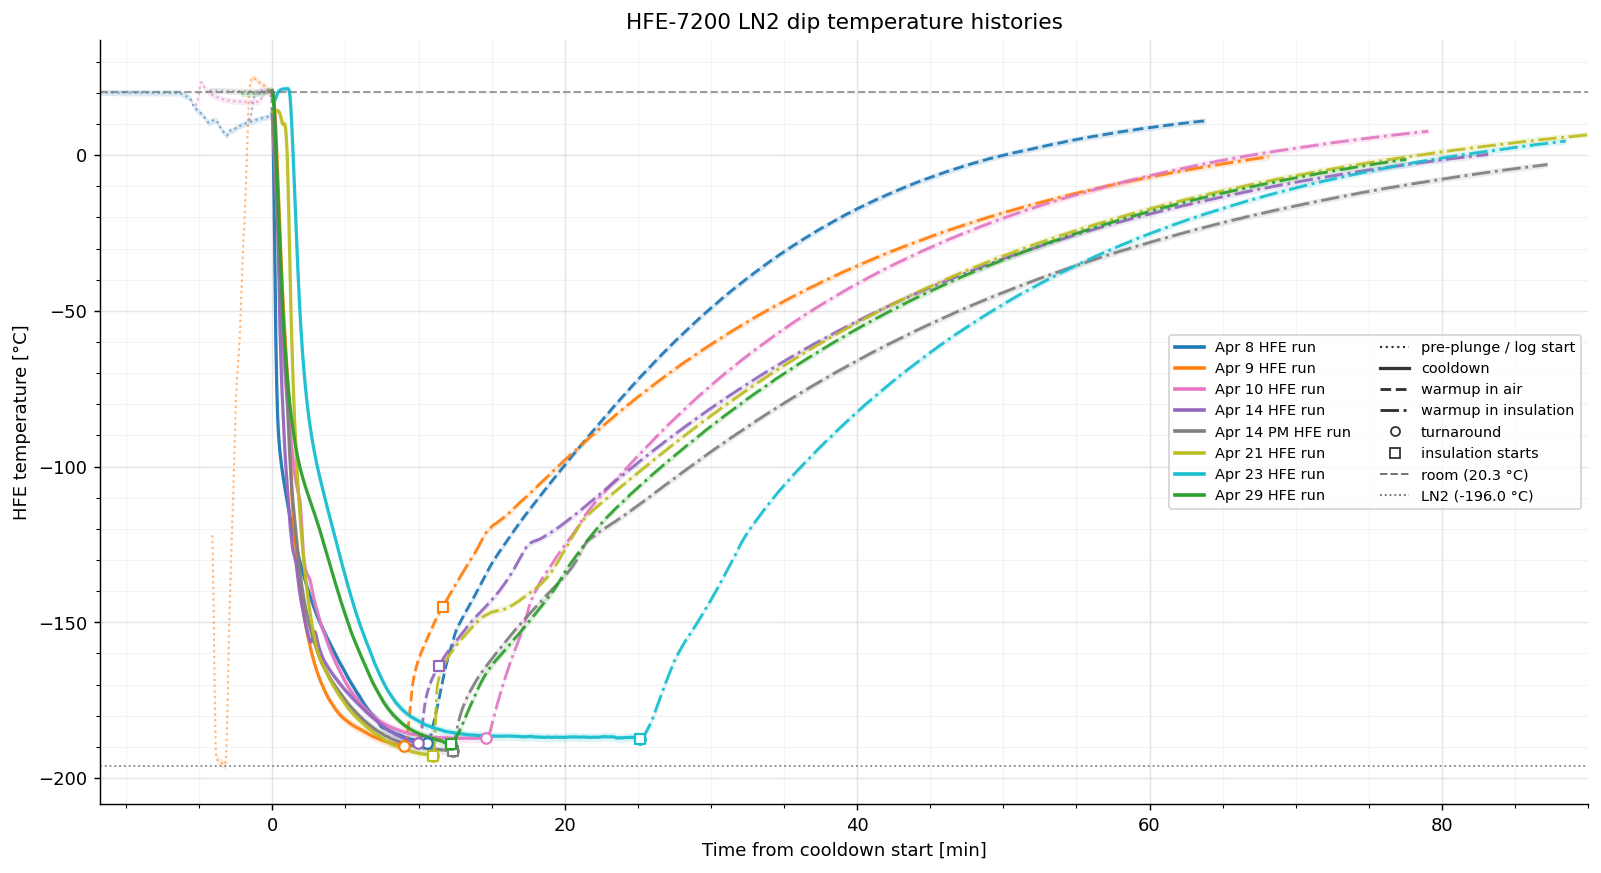

In [3]:
plot_hfe7200_ln2_dip_temperature_overview(review)

## dT/dt

These curves use the derivative of the smoothed HFE temperature. Negative `dT/dt` means the sample is cooling; positive `dT/dt` means it is warming. Plotted against temperature, the rate history makes it easier to see where the Apr 14 PM, Apr 21, Apr 23, and Apr 29 runs change behavior across the transition region. The shaded band is the random-noise contribution to `dT/dt`, `σ(dT/dt) ≈ σ_T / W_{smooth}`, where `σ_T` is a MAD-based estimate of the per-sample random noise from the raw–smoothed residuals (~0.04 °C for these runs) and `W_{smooth} = 10 s`. The Type-T calibration tolerance (±max(1 °C, 0.75% |T|)) is not propagated here because a near-constant systematic offset cancels in the derivative. The y-axis uses a piecewise linear scale that keeps `y = 0` at the vertical center and auto-scales the positive and negative halves independently, so the warmup region is no longer compressed by the much larger cooldown slopes.

<Axes: title={'center': 'Calibrated HFE temperature-rate histories'}, xlabel='HFE temperature [°C]', ylabel='Temperature rate dT/dt [°C/s]'>

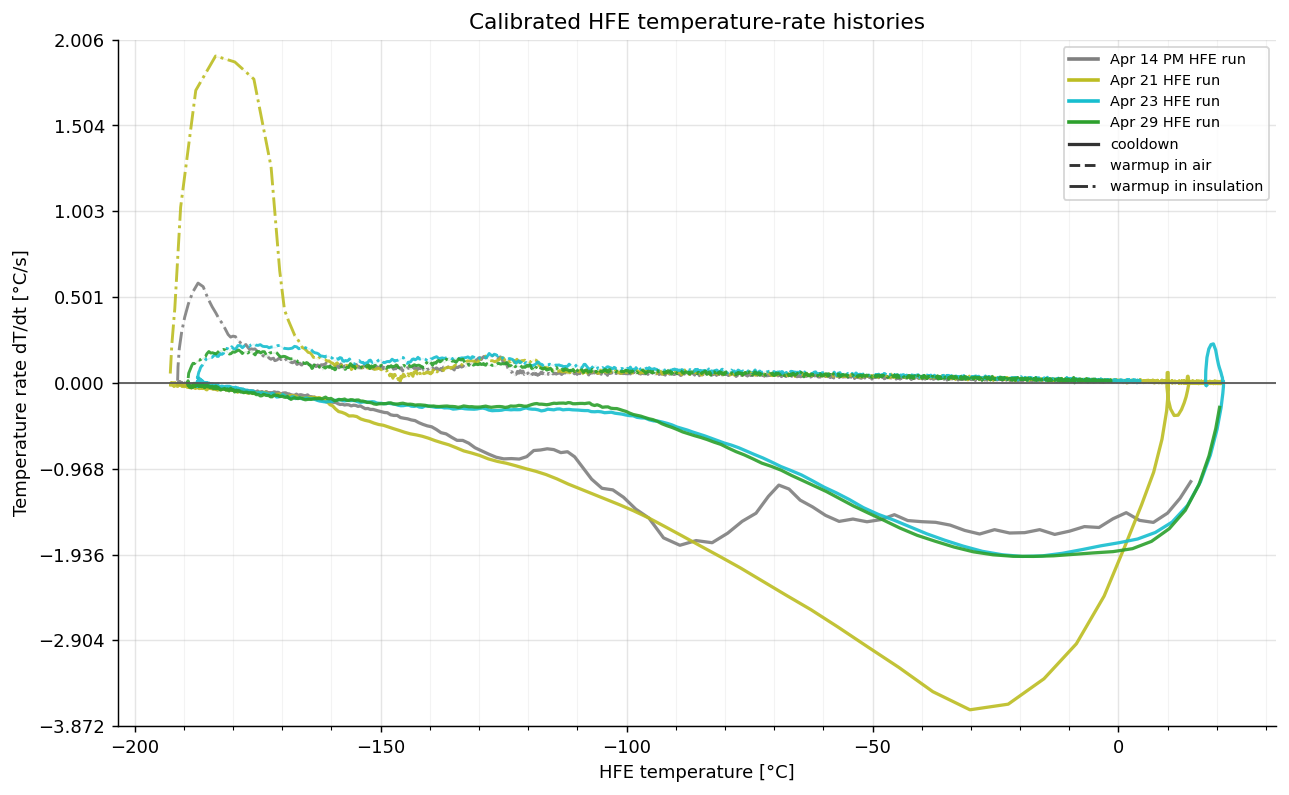

In [4]:
plot_hfe7200_ln2_dip_rate_overview(review)

## DSC-like Warmup Curves

For each warmup branch, the measured heating rate per gram is estimated as `q_{meas}/m = -(C_{app} dT/dt)/m`. A linear ambient-heating background is then fit over `-75 °C` to `0 °C`, `q_{bg}/m = -k_{run}(T_{room} - T_{HFE})`, and the plotted event signal is `q_{event}/m = q_{bg}/m - q_{meas}/m`. With that sign convention, exothermic release plots upward. The dotted trace for each run is the pre-background-removal heat flow `-q_{meas}/m` (same Exo Up convention) — comparing the solid and dotted curves shows how much of the signal the linear background is removing. The shaded per-run band is the random-noise contribution propagated through the capacity model, `σ(q/m) = (C_{app}/m) · σ_T / W_{smooth}`, where `σ_T` is the per-run MAD-based random-noise estimate (~0.04 °C) and `W_{smooth} = 10 s`. The calibration tolerance is not included because it is a near-constant offset that cancels in `dT/dt`. This overview shows all seven runs together; the 3M comparison below keeps only the runs that track 3M.

<Axes: title={'center': 'HFE-7200 DSC-like warmup curves'}, xlabel='HFE temperature [°C]', ylabel='DSC-like event heat flow (Exo Up) [W/g]'>

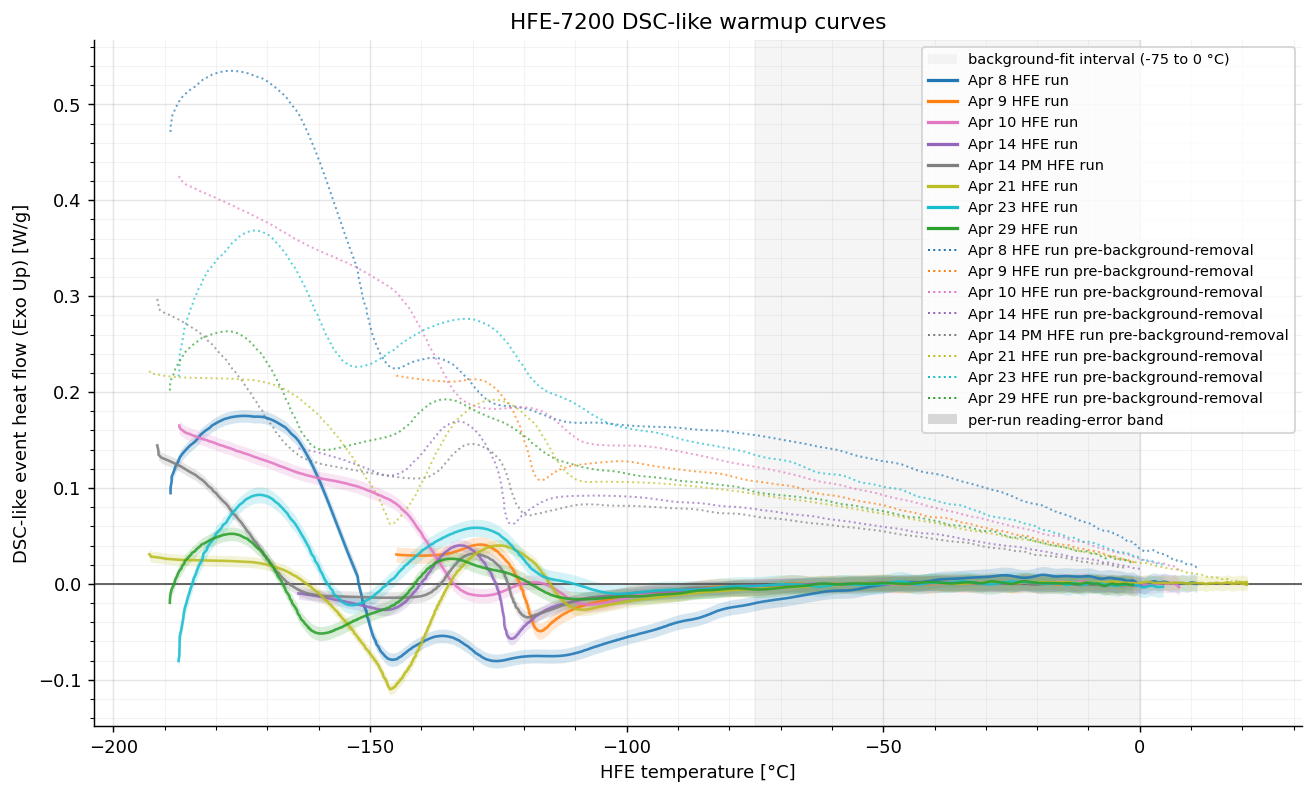

In [5]:
plot_hfe7200_ln2_dip_dsc_like_overview(review, run_names=review.run_order, include_mean_band=False)

## Phase Transition Candidates

Candidate transition temperatures are estimated from extrema in the DSC-like warmup curves within expected HFE-7200 windows: glass transition (`-175 °C` to `-155 °C`, minimum), cold crystallization (`-150 °C` to `-110 °C`, maximum), and melt (`-125 °C` to `-90 °C`, minimum). The table includes the latest Apr 29 run and marks partial-window candidates where the curve does not fully cover the search interval.

In [6]:
display(
    review.phase_transition_summary.style.format(
        {
            'Candidate temperature [°C]': '{:.1f}',
            'Heat flow [W/g]': '{:.4f}',
        },
        na_rep='not available',
    )
)

,Source,Source type,Transition,Candidate temperature [°C],Heat flow [W/g],Search window [°C],Feature,Status
0,Apr 8 HFE run,run,Glass transition,-155.0,0.0421,-175 to -155,minimum,candidate
1,Apr 8 HFE run,run,Cold crystallization,-149.8,-0.0482,-150 to -110,maximum,candidate
2,Apr 8 HFE run,run,Melt temperature,-124.9,-0.0804,-125 to -90,minimum,candidate
3,Apr 9 HFE run,run,Glass transition,not available,not available,-175 to -155,minimum,not covered
4,Apr 9 HFE run,run,Cold crystallization,-128.5,0.0410,-150 to -110,maximum,candidate (partial window)
5,Apr 9 HFE run,run,Melt temperature,-116.8,-0.0493,-125 to -90,minimum,candidate
6,Apr 10 HFE run,run,Glass transition,-155.3,0.1055,-175 to -155,minimum,candidate
7,Apr 10 HFE run,run,Cold crystallization,-149.8,0.0964,-150 to -110,maximum,candidate
8,Apr 10 HFE run,run,Melt temperature,-107.3,-0.0216,-125 to -90,minimum,candidate
9,Apr 14 HFE run,run,Glass transition,-155.2,-0.0182,-175 to -155,minimum,candidate (partial window)


## Comparison With 3M

The 3M curve is the digitized vendor DSC trace baseline-referenced by subtracting a linear fit over `-75 °C` to `0 °C`. The HFE reference is the **mean of the two Apr 14 runs** (Apr 14 HFE and Apr 14 PM HFE), the pair whose DSC-like event curves are most coherent with each other in the transition region. The measured mean curve has its ambient-heating background removed over the same temperature interval, so both the 3M and the solid measured curve are compared relative to a zero baseline. The dotted raw traces show `-q_{meas}/m = (C_{app} dT/dt)/m` directly with no background removal; they are physically positive during warmup (since `dT/dt > 0`) and taper toward zero as the sample approaches ambient. The red band is the combined uncertainty, computed from the run-to-run spread and the propagated random-noise floor.

<Axes: xlabel='HFE temperature [°C]', ylabel='Baseline-referenced heat flow (Exo Up) [W/g]'>

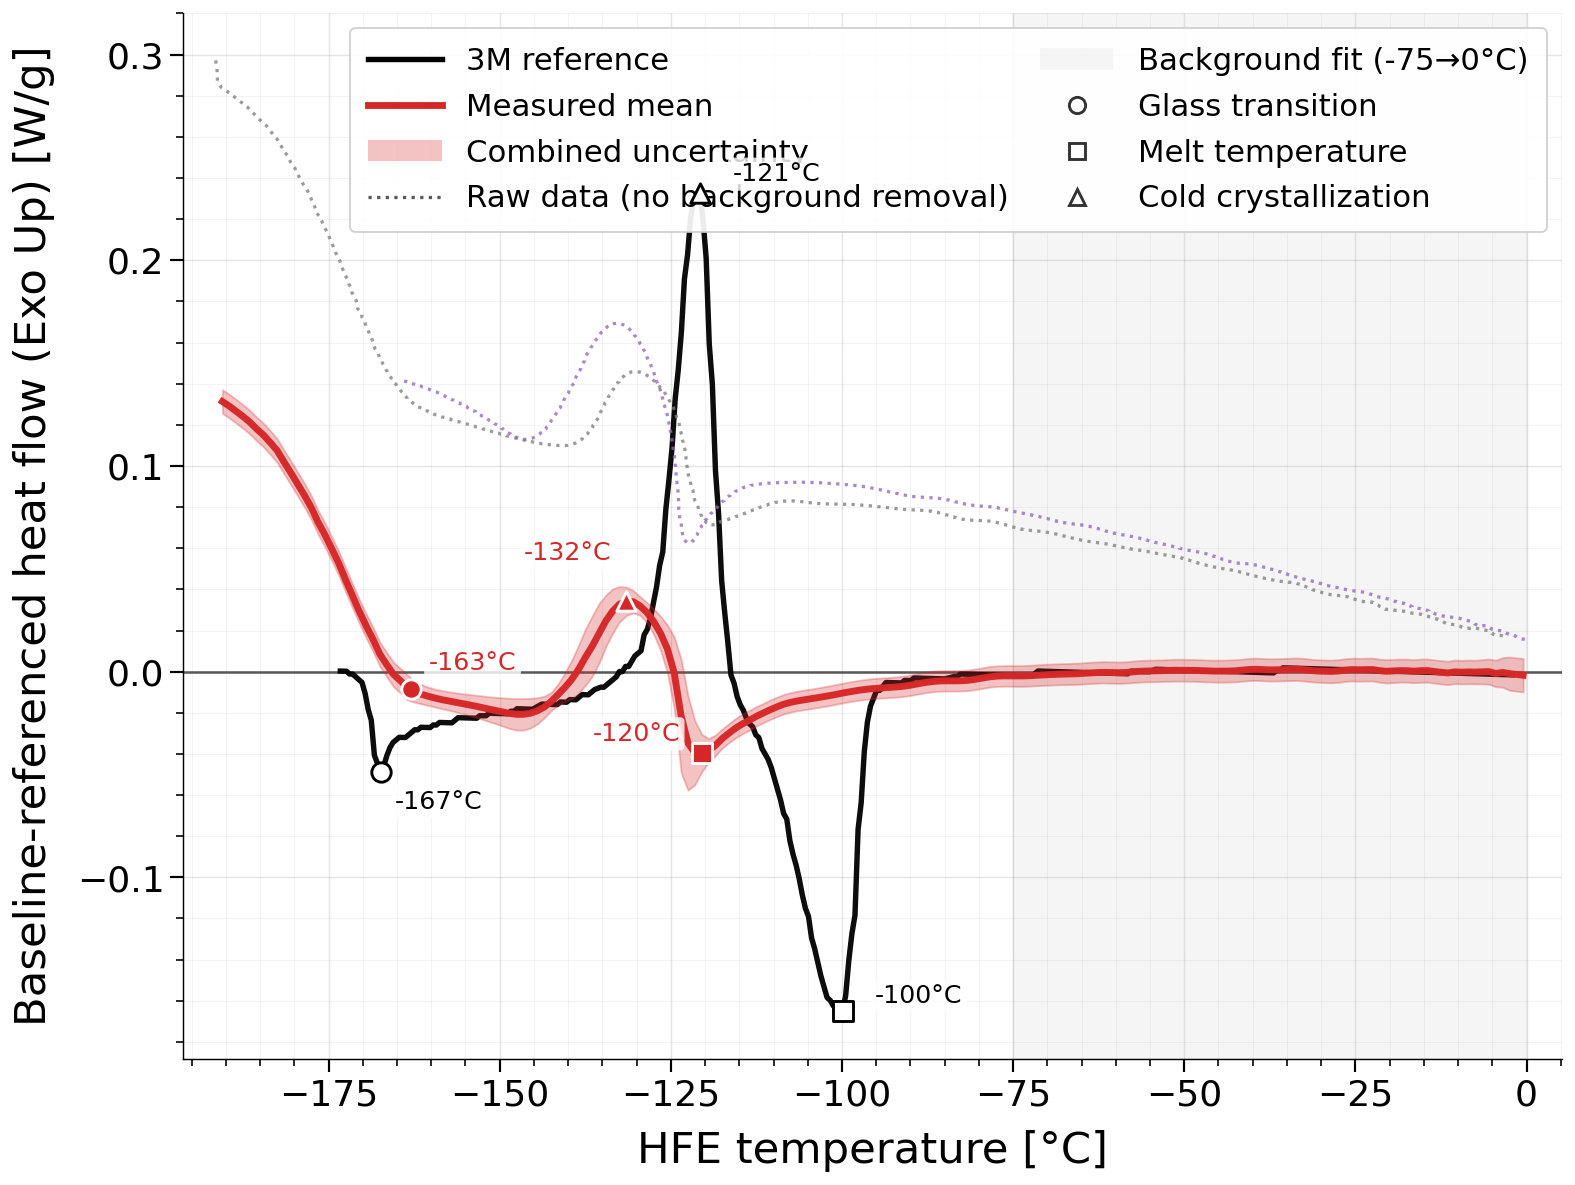

In [7]:
plot_hfe7200_ln2_dip_vs_three_m(review)